In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("visualizations", exist_ok=True)

print("Libraries imported successfully!")
print("Visualizations folder created!")

Libraries imported successfully!
Visualizations folder created!


In [18]:
df = pd.read_csv("/content/CarDekho_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [19]:
# Check dataset information
print("Dataset Information:")
print("--------------------")

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
--------------------
Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [20]:
# Check and remove duplicate rows

print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Duplicate rows before cleaning: 2
Duplicate rows after cleaning: 0
Dataset shape after cleaning: (299, 9)


In [35]:
# Create Car Age column

CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Year"]


In [36]:
# Calculate Depreciation

df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]

df["Depreciation_Percentage"] = (
    (df["Present_Price"] - df["Selling_Price"])
    / df["Present_Price"]
) * 100

print("Average Depreciation Percentage:",
      df["Depreciation_Percentage"].mean())

Average Depreciation Percentage: 36.62197411590638


In [22]:
# Basic Statistical Summary

print("Statistical Summary:")
print("--------------------")

df.describe()

Statistical Summary:
--------------------


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478,12.384615
std,2.896868,4.984240,8.567887,39015.170352,0.248720,2.896868
min,2003.000000,0.100000,0.320000,500.000000,0.000000,8.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000,10.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000,12.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000,14.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,23.000000


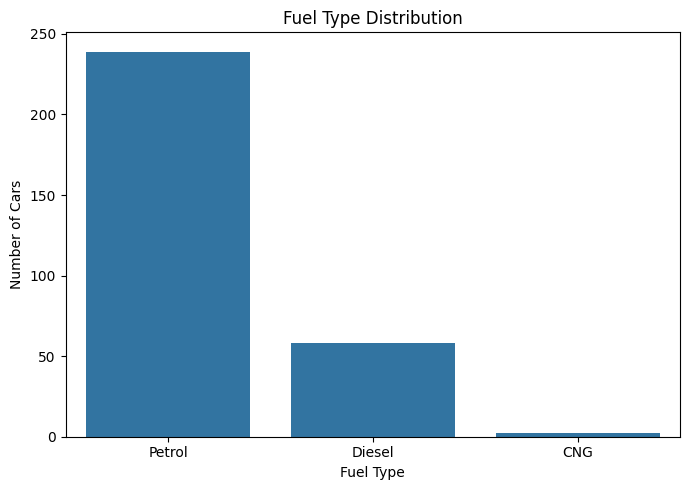

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Fuel_Type"
)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "visualizations/01_Fuel_Type_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

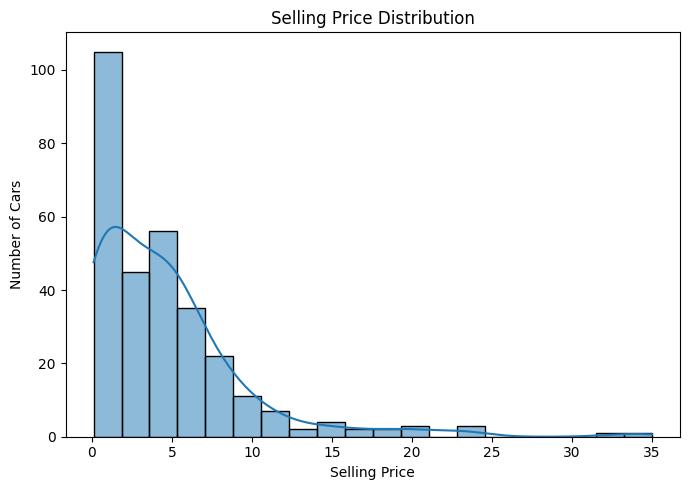

In [24]:
# 2. Selling Price Distribution

plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="Selling_Price",
    bins=20,
    kde=True
)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "visualizations/02_Selling_Price_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

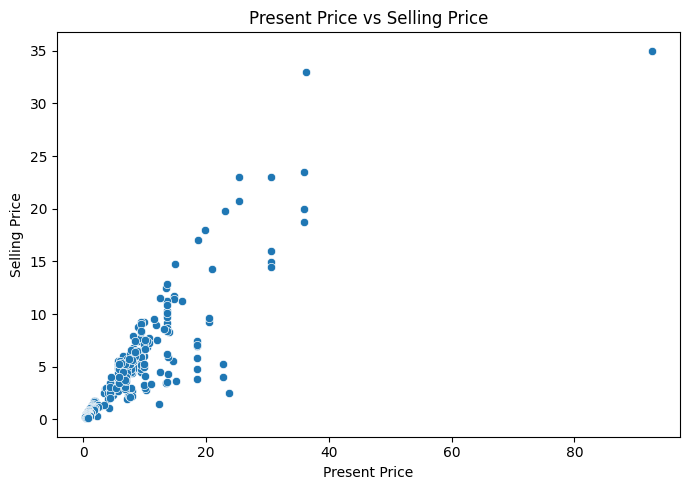

In [25]:
# 3. Present Price vs Selling Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.tight_layout()

plt.savefig(
    "visualizations/03_Present_Price_vs_Selling_Price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

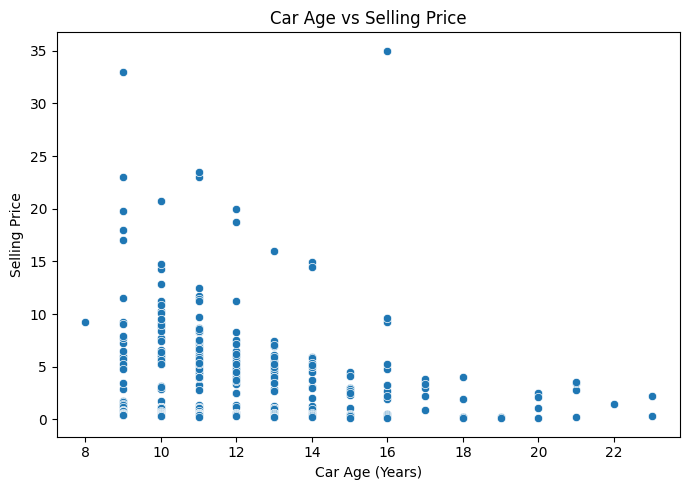

In [26]:
# 4. Car Age vs Selling Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.tight_layout()

plt.savefig(
    "visualizations/04_Car_Age_vs_Selling_Price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

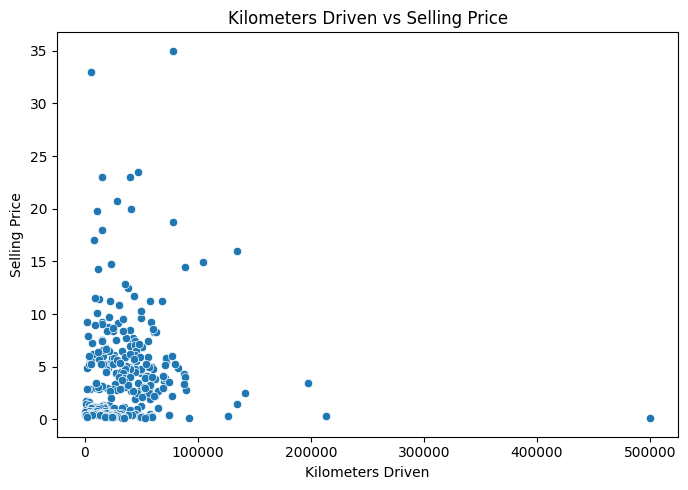

In [27]:
# 5. Kilometers Driven vs Selling Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.tight_layout()

plt.savefig(
    "visualizations/05_Kms_Driven_vs_Selling_Price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Average Selling Price by Fuel Type:
Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


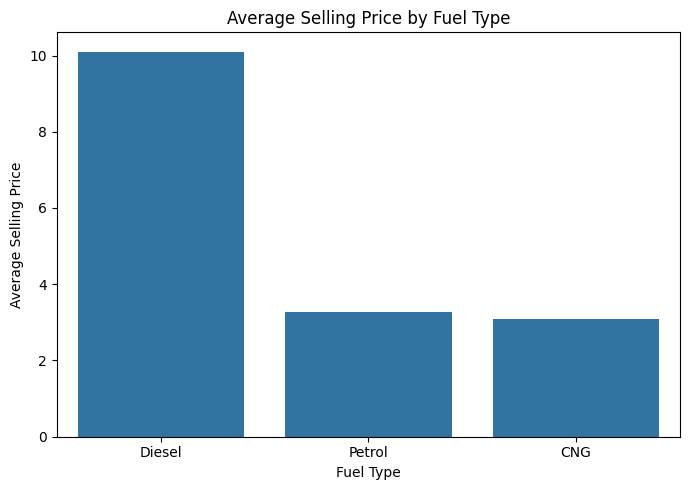

In [28]:
# 6. Average Selling Price by Fuel Type

fuel_price = (
    df.groupby("Fuel_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Selling Price by Fuel Type:")
print(fuel_price)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=fuel_price.index,
    y=fuel_price.values
)

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")

plt.tight_layout()

plt.savefig(
    "visualizations/06_Average_Selling_Price_by_Fuel_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

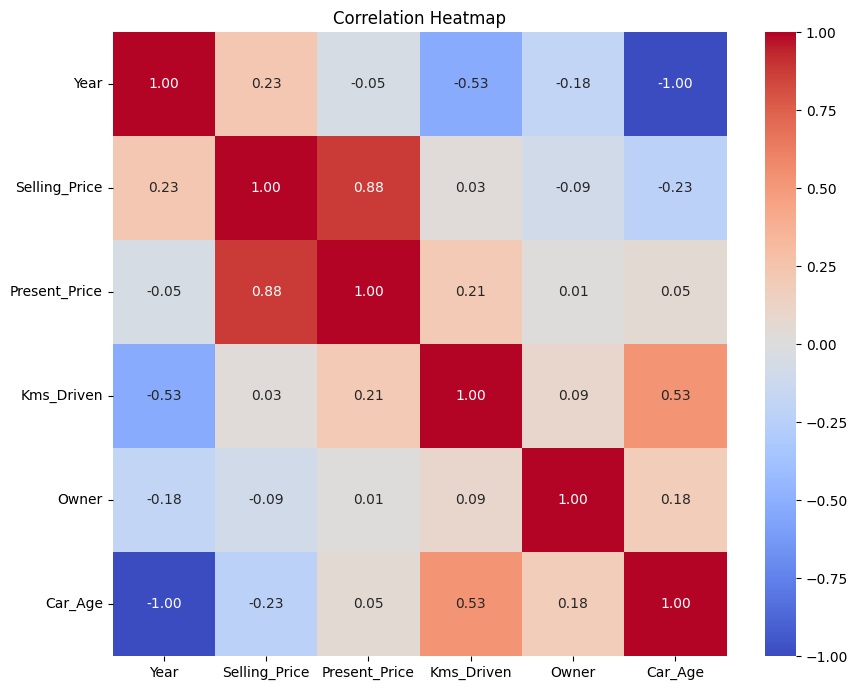

In [29]:
# 7. Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "visualizations/07_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Average Selling Price by Transmission:
Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


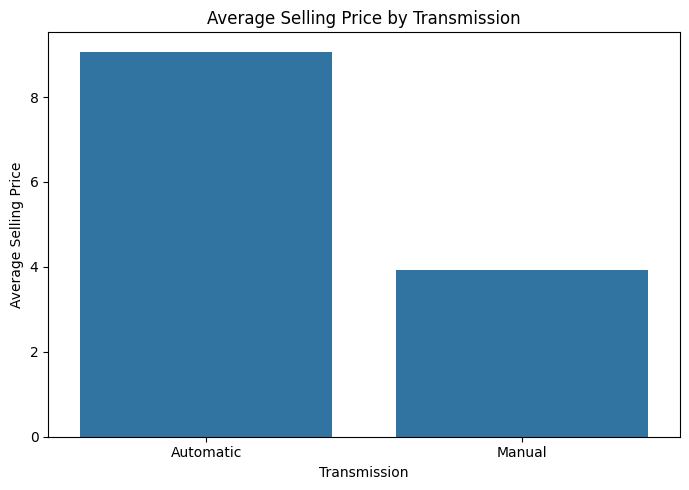

In [30]:
# 8. Average Selling Price by Transmission

transmission_price = (
    df.groupby("Transmission")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Selling Price by Transmission:")
print(transmission_price)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=transmission_price.index,
    y=transmission_price.values
)

plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")

plt.tight_layout()

plt.savefig(
    "visualizations/08_Average_Selling_Price_by_Transmission.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()